In [1]:
from pathlib import Path
import pandas as pd

project_path = Path(
    r"D:\MScProjects\labour-market-intelligence"
)

raw_path = project_path / "data" / "raw"
processed_path = project_path / "data" / "processed"

print("RAW DATA FILES\n")

for file in sorted(raw_path.rglob("*")):
    if file.is_file():
        print(file.relative_to(raw_path))

RAW DATA FILES

onet\Essential Skills.xlsx
onet\Job Titles.xlsx
onet\Occupation Data.xlsx
onet\Software Skills.xlsx
ons\ONS_ASHE_Local_Authority 2023.zip
ons\ONS_ASHE_Local_Authority 2024.zip
ons\ONS_ASHE_Local_Authority 2025.zip
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.10a   Paid hours worked - Basic 2023.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.10b   Paid hours worked - Basic 2023 CV.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.11a   Paid hours worked - Overtime 2023.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.11b   Paid hours worked - Overtime 2023 CV.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.1a   Weekly pay - Gross 2023.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.1b   Weekly pay - Gross 2023 CV.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.2a   Weekly pay - Excluding overtime 2023.xlsx
ons\ONS_ASHE_Occupation_2023\Occupation SOC20 (4) Table 14.

In [2]:
# ============================================================
# STEP 2.2
# Inspect geographical job-advert data in ONS Textkernel file
# ============================================================

textkernel_path = (
    raw_path / "ons" / "ONS_Textkernel_Job_Adverts.xlsx"
)

xls = pd.ExcelFile(textkernel_path)

print("TEXTKERNEL SHEETS:\n")

for i, sheet in enumerate(xls.sheet_names):
    print(i, ":", sheet)

TEXTKERNEL SHEETS:

0 : Cover
1 : Contents
2 : Notes
3 : 1.Region NSA
4 : 2.Occupation 2-Digit NSA
5 : 3.Occupation 4-Digit NSA


In [3]:
# ============================================================
# STEP 2.3
# Inspect regional job-advert structure
# ============================================================

region_raw = pd.read_excel(
    textkernel_path,
    sheet_name="1.Region NSA",
    header=None
)

print("Shape:", region_raw.shape)
print("\nFirst 15 rows:")
display(region_raw.head(15))

Shape: (107, 16)

First 15 rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Table 1: New online job adverts in the UK, spl...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table. See Notes w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Back to Notes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Back to Contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Month,Total UK,East Midlands,East of England,London,North East,North West,South East,South West,West Midlands,Yorkshire and The Humber,England,Scotland,Wales,Northern Ireland,Unknown
5,2018-01-01 00:00:00,993156,51439,77949,225254,21161,83946,136388,74141,84350,57724,812337,36798,21102,14023,108896
6,2018-02-01 00:00:00,854140,43551,65483,199366,17357,70362,112140,61411,67446,49907,687010,33639,18109,11204,104178
7,2018-03-01 00:00:00,921648,46442,71240,211038,18924,77620,124705,68365,73818,54301,746437,36615,19507,12138,106951
8,2018-04-01 00:00:00,819751,42730,65726,183039,16650,67467,112642,60435,69484,48608,666771,32915,17434,10457,92174
9,2018-05-01 00:00:00,891434,48579,72531,200912,18147,76771,126511,67709,80669,54338,746152,38026,17315,12405,77536


In [4]:
# ============================================================
# STEP 2.4
# Prepare regional job-advert demand for proposal locations
# ============================================================

region_demand = pd.read_excel(
    textkernel_path,
    sheet_name="1.Region NSA",
    header=4
)

# Convert Month to datetime
region_demand["Month"] = pd.to_datetime(
    region_demand["Month"],
    errors="coerce"
)

# Keep project analysis years
region_demand = region_demand[
    region_demand["Month"].dt.year.isin([2023, 2024, 2025])
].copy()

# Keep proposal-relevant regional contexts
regional_demand = region_demand[
    [
        "Month",
        "London",
        "North West",
        "West Midlands"
    ]
].copy()

# Convert wide -> long
regional_demand = regional_demand.melt(
    id_vars="Month",
    var_name="Region",
    value_name="Job_Adverts"
)

# Add year
regional_demand["Year"] = regional_demand["Month"].dt.year

# Add proposal interpretation labels
location_map = {
    "London": "London",
    "North West": "Manchester regional context",
    "West Midlands": "Birmingham regional context"
}

regional_demand["Location_Context"] = (
    regional_demand["Region"].map(location_map)
)

# Ensure demand is numeric
regional_demand["Job_Adverts"] = pd.to_numeric(
    regional_demand["Job_Adverts"],
    errors="coerce"
)

print("Shape:", regional_demand.shape)

print("\nDate range:")
print(
    regional_demand["Month"].min(),
    "to",
    regional_demand["Month"].max()
)

print("\nRows by region/year:")
print(
    regional_demand
    .groupby(["Year", "Region"])
    .agg(
        Observed_Months=("Job_Adverts", "count"),
        Missing_Values=("Job_Adverts", lambda x: x.isna().sum()),
        Average_Monthly_Adverts=("Job_Adverts", "mean")
    )
    .round(1)
)

print("\nFirst 10 rows:")
print(regional_demand.head(10).to_string(index=False))

Shape: (108, 5)

Date range:
2023-01-01 00:00:00 to 2025-12-01 00:00:00

Rows by region/year:
                    Observed_Months  Missing_Values  Average_Monthly_Adverts
Year Region                                                                 
2023 London                      12               0                 164341.2
     North West                  12               0                  88384.1
     West Midlands               12               0                  67152.2
2024 London                      12               0                 118799.3
     North West                  12               0                  77669.0
     West Midlands               12               0                  58163.8
2025 London                      12               0                 121131.8
     North West                  12               0                  77827.8
     West Midlands               12               0                  59020.1

First 10 rows:
     Month Region  Job_Adverts  Year Locati

In [5]:
# ============================================================
# STEP 2.5
# Regional demand summary and change, 2023–2025
# ============================================================

regional_demand_summary = (
    regional_demand
    .groupby(
        ["Year", "Region", "Location_Context"],
        as_index=False
    )
    .agg(
        Observed_Months=("Job_Adverts", "count"),
        Total_Job_Adverts=("Job_Adverts", "sum"),
        Average_Monthly_Adverts=("Job_Adverts", "mean")
    )
)

regional_demand_summary["Average_Monthly_Adverts"] = (
    regional_demand_summary["Average_Monthly_Adverts"].round(1)
)

regional_demand_summary = regional_demand_summary.sort_values(
    ["Region", "Year"]
)

# Year-on-year change
regional_demand_summary["YoY_Demand_Growth_Pct"] = (
    regional_demand_summary
    .groupby("Region")["Average_Monthly_Adverts"]
    .pct_change() * 100
).round(2)

print("REGIONAL DEMAND SUMMARY")
print(regional_demand_summary.to_string(index=False))


# ------------------------------------------------------------
# Overall change from 2023 to 2025
# ------------------------------------------------------------

regional_change = (
    regional_demand_summary[
        regional_demand_summary["Year"].isin([2023, 2025])
    ]
    .pivot(
        index=["Region", "Location_Context"],
        columns="Year",
        values="Average_Monthly_Adverts"
    )
    .reset_index()
)

regional_change.columns.name = None

regional_change = regional_change.rename(
    columns={
        2023: "Average_Monthly_Adverts_2023",
        2025: "Average_Monthly_Adverts_2025"
    }
)

regional_change["Demand_Change_2023_2025_Pct"] = (
    (
        regional_change["Average_Monthly_Adverts_2025"]
        / regional_change["Average_Monthly_Adverts_2023"]
        - 1
    ) * 100
).round(2)

print("\n2023–2025 REGIONAL DEMAND CHANGE")
print(regional_change.to_string(index=False))

REGIONAL DEMAND SUMMARY
 Year        Region            Location_Context  Observed_Months  Total_Job_Adverts  Average_Monthly_Adverts  YoY_Demand_Growth_Pct
 2023        London                      London               12            1972094                 164341.2                    NaN
 2024        London                      London               12            1425592                 118799.3                 -27.71
 2025        London                      London               12            1453582                 121131.8                   1.96
 2023    North West Manchester regional context               12            1060609                  88384.1                    NaN
 2024    North West Manchester regional context               12             932028                  77669.0                 -12.12
 2025    North West Manchester regional context               12             933934                  77827.8                   0.20
 2023 West Midlands Birmingham regional context     

In [6]:
# ============================================================
# STEP 2.6 — Regional demand + digital salary integration
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

# ------------------------------------------------------------
# 1. Load regional digital salary data already created
# ------------------------------------------------------------

regional_salary = pd.read_csv(
    processed_path / "regional_digital_salary_2023_2025.csv"
)

print("REGIONAL SALARY")
print("Shape:", regional_salary.shape)
print(regional_salary.head().to_string(index=False))


# ------------------------------------------------------------
# 2. Use the regional demand summary created in Step 2.5
#
# Expected object already in memory:
# regional_demand_summary
# ------------------------------------------------------------

print("\nREGIONAL DEMAND")
print("Shape:", regional_demand_summary.shape)
print(regional_demand_summary.to_string(index=False))


# ------------------------------------------------------------
# 3. Check merge keys
# ------------------------------------------------------------

regional_salary["Year"] = pd.to_numeric(
    regional_salary["Year"],
    errors="coerce"
).astype(int)

regional_demand_summary["Year"] = pd.to_numeric(
    regional_demand_summary["Year"],
    errors="coerce"
).astype(int)

print("\nSalary regions:")
print(sorted(regional_salary["Region"].dropna().unique()))

print("\nDemand regions:")
print(sorted(regional_demand_summary["Region"].dropna().unique()))


# ------------------------------------------------------------
# 4. Merge
#
# Regional demand = ALL online job adverts in the region.
# Salary = digital occupation-specific salary.
#
# Therefore regional demand is repeated for each digital
# occupation within the same region/year.
# ------------------------------------------------------------

regional_integrated = regional_salary.merge(
    regional_demand_summary[
        [
            "Year",
            "Region",
            "Average_Monthly_Adverts",
            "YoY_Demand_Growth_Pct"
        ]
    ],
    on=["Year", "Region"],
    how="left"
)


# ------------------------------------------------------------
# 5. Rename demand fields so their meaning is explicit
# ------------------------------------------------------------

regional_integrated = regional_integrated.rename(
    columns={
        "Average_Monthly_Adverts":
            "Regional_Average_Monthly_Adverts",

        "YoY_Demand_Growth_Pct":
            "Regional_Demand_Growth_Pct"
    }
)


# ------------------------------------------------------------
# 6. Sort and inspect
# ------------------------------------------------------------

regional_integrated = regional_integrated.sort_values(
    ["Year", "Region", "SOC_Code"]
).reset_index(drop=True)

print("\nINTEGRATED REGIONAL DATASET")
print("Shape:", regional_integrated.shape)

print("\nMissing values:")
print(regional_integrated.isna().sum())

print("\nDataset:")
print(regional_integrated.to_string(index=False))


# ------------------------------------------------------------
# 7. Save
# ------------------------------------------------------------

output_path = (
    processed_path /
    "regional_demand_salary_integrated_2023_2025.csv"
)

regional_integrated.to_csv(
    output_path,
    index=False
)

print("\nSaved:", output_path)

REGIONAL SALARY
Shape: (27, 6)
 Year        Region            Location_Context  SOC_Code Skill_Category  Median_Annual_Salary
 2023        London                      London      2135  Cybersecurity                   NaN
 2023    North West Manchester regional context      2135  Cybersecurity               59001.0
 2023 West Midlands Birmingham regional context      2135  Cybersecurity               44505.0
 2023        London                      London      3544 Data Analytics               40198.0
 2023    North West Manchester regional context      3544 Data Analytics               31496.0

REGIONAL DEMAND
Shape: (9, 7)
 Year        Region            Location_Context  Observed_Months  Total_Job_Adverts  Average_Monthly_Adverts  YoY_Demand_Growth_Pct
 2023        London                      London               12            1972094                 164341.2                    NaN
 2024        London                      London               12            1425592                 1187

In [7]:
# ============================================================
# STEP 2.7 — Final regional analytical dataset
# Regional demand + salary + salary premium/change
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

# ------------------------------------------------------------
# 1. Load datasets already produced
# ------------------------------------------------------------

regional_integrated = pd.read_csv(
    processed_path /
    "regional_demand_salary_integrated_2023_2025.csv"
)

regional_premiums = pd.read_csv(
    processed_path /
    "regional_salary_premiums_2023_2025.csv"
)

salary_change = pd.read_csv(
    processed_path /
    "regional_salary_change_2023_2025.csv"
)

print("Integrated:", regional_integrated.shape)
print("Premiums:", regional_premiums.shape)
print("Salary change:", salary_change.shape)


# ------------------------------------------------------------
# 2. Prepare salary-premium fields
# ------------------------------------------------------------

premium_cols = regional_premiums[
    [
        "Year",
        "Region",
        "SOC_Code",
        "West_Midlands_Baseline",
        "Salary_Premium_GBP",
        "Salary_Premium_Pct"
    ]
].copy()

premium_cols["SOC_Code"] = (
    premium_cols["SOC_Code"].astype(str)
)

regional_integrated["SOC_Code"] = (
    regional_integrated["SOC_Code"].astype(str)
)


# ------------------------------------------------------------
# 3. Merge salary premiums
# ------------------------------------------------------------

regional_final = regional_integrated.merge(
    premium_cols,
    on=["Year", "Region", "SOC_Code"],
    how="left"
)


# ------------------------------------------------------------
# 4. Prepare 2023–2025 salary-change fields
# ------------------------------------------------------------

change_cols = salary_change[
    [
        "Region",
        "SOC_Code",
        "Salary_Change_GBP_2023_2025",
        "Salary_Change_Pct_2023_2025"
    ]
].copy()

change_cols["SOC_Code"] = (
    change_cols["SOC_Code"].astype(str)
)


# Salary change describes the occupation-region over the
# complete 2023–2025 period, so it is attached to each
# corresponding year row for dashboard/filtering purposes.

regional_final = regional_final.merge(
    change_cols,
    on=["Region", "SOC_Code"],
    how="left"
)


# ------------------------------------------------------------
# 5. Add explicit data-quality flag
# ------------------------------------------------------------

regional_final["Salary_Data_Quality"] = (
    regional_final["Median_Annual_Salary"]
    .apply(
        lambda x: "Suppressed / unavailable"
        if pd.isna(x)
        else "Available"
    )
)


# ------------------------------------------------------------
# 6. Sort final dataset
# ------------------------------------------------------------

regional_final = regional_final.sort_values(
    ["Year", "Region", "SOC_Code"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 7. Inspect
# ------------------------------------------------------------

print("\nFINAL REGIONAL DATASET")
print("Shape:", regional_final.shape)

print("\nColumns:")
print(regional_final.columns.tolist())

print("\nMissing values:")
print(regional_final.isna().sum())

print("\nSalary data-quality counts:")
print(
    regional_final["Salary_Data_Quality"]
    .value_counts()
)

print("\nFinal dataset:")
print(regional_final.to_string(index=False))


# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

output_path = (
    processed_path /
    "regional_labour_market_final_2023_2025.csv"
)

regional_final.to_csv(
    output_path,
    index=False
)

print("\nSaved:", output_path)

Integrated: (27, 8)
Premiums: (27, 9)
Salary change: (9, 8)

FINAL REGIONAL DATASET
Shape: (27, 14)

Columns:
['Year', 'Region', 'Location_Context', 'SOC_Code', 'Skill_Category', 'Median_Annual_Salary', 'Regional_Average_Monthly_Adverts', 'Regional_Demand_Growth_Pct', 'West_Midlands_Baseline', 'Salary_Premium_GBP', 'Salary_Premium_Pct', 'Salary_Change_GBP_2023_2025', 'Salary_Change_Pct_2023_2025', 'Salary_Data_Quality']

Missing values:
Year                                0
Region                              0
Location_Context                    0
SOC_Code                            0
Skill_Category                      0
Median_Annual_Salary                4
Regional_Average_Monthly_Adverts    0
Regional_Demand_Growth_Pct          9
West_Midlands_Baseline              3
Salary_Premium_GBP                  6
Salary_Premium_Pct                  6
Salary_Change_GBP_2023_2025         6
Salary_Change_Pct_2023_2025         6
Salary_Data_Quality                 0
dtype: int64

Salary data-q

In [8]:
# ============================================================
# STEP 3.1 — Audit existing skills evidence
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

# Files already created in earlier notebooks
files = {
    "O*NET Essential Skills":
        "onet_selected_skills.csv",

    "Digital Software Skill Classification":
        "digital_skill_classification.csv",

    "NLP Job Title Classification":
        "nlp_job_title_classification.csv"
}

datasets = {}

for name, filename in files.items():

    path = processed_path / filename

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print("File:", filename)
    print("Exists:", path.exists())

    if path.exists():

        df = pd.read_csv(path)
        datasets[name] = df

        print("Shape:", df.shape)

        print("\nColumns:")
        print(df.columns.tolist())

        print("\nMissing values:")
        print(df.isna().sum())

        print("\nFirst 5 rows:")
        print(df.head().to_string(index=False))


# ============================================================
# Detailed checks
# ============================================================

# ------------------------------------------------------------
# 1. O*NET Essential Skills
# ------------------------------------------------------------

if "O*NET Essential Skills" in datasets:

    essential = datasets["O*NET Essential Skills"]

    print("\n" + "=" * 80)
    print("ESSENTIAL SKILLS COVERAGE")
    print("=" * 80)

    print("\nOccupations:")
    print(sorted(essential["Title"].dropna().unique()))

    print("\nNumber of occupations:")
    print(essential["Title"].nunique())

    print("\nNumber of unique skills:")
    print(essential["Element Name"].nunique())

    print("\nScale names:")
    print(essential["Scale Name"].value_counts(dropna=False))

    print("\nRows per occupation:")
    print(
        essential.groupby("Title")
        .size()
        .sort_values(ascending=False)
    )


# ------------------------------------------------------------
# 2. Software / technology classification
# ------------------------------------------------------------

if "Digital Software Skill Classification" in datasets:

    digital_skills = datasets[
        "Digital Software Skill Classification"
    ]

    print("\n" + "=" * 80)
    print("DIGITAL TECHNOLOGY COVERAGE")
    print("=" * 80)

    print("\nSkill categories:")
    print(
        digital_skills["Skill_Category"]
        .value_counts(dropna=False)
    )

    print("\nUnique O*NET occupations:")
    print(digital_skills["Title"].nunique())

    print("\nUnique technologies:")
    print(
        digital_skills["Workplace Example"].nunique()
    )

    print("\nHot Technology:")
    print(
        digital_skills["Hot Technology"]
        .value_counts(dropna=False)
    )

    print("\nIn Demand:")
    print(
        digital_skills["In Demand"]
        .value_counts(dropna=False)
    )

    print("\nUnique technologies by category:")

    print(
        digital_skills
        .groupby("Skill_Category")["Workplace Example"]
        .nunique()
        .sort_values(ascending=False)
    )


# ------------------------------------------------------------
# 3. NLP job-title classification
# ------------------------------------------------------------

if "NLP Job Title Classification" in datasets:

    nlp = datasets["NLP Job Title Classification"]

    print("\n" + "=" * 80)
    print("NLP JOB-TITLE COVERAGE")
    print("=" * 80)

    print("\nNLP categories:")
    print(
        nlp["NLP_Category"]
        .value_counts(dropna=False)
    )

    print("\nUnique classified job titles:")
    print(
        nlp["Clean_Job_Title"].nunique()
    )

    print("\nUnique O*NET occupations represented:")
    print(
        nlp["Title"].nunique()
    )

    print("\nTitles by NLP category:")

    print(
        nlp.groupby("NLP_Category")["Clean_Job_Title"]
        .nunique()
        .sort_values(ascending=False)
    )


# ============================================================
# Final audit summary
# ============================================================

print("\n" + "=" * 80)
print("STEP 3.1 AUDIT COMPLETE")
print("=" * 80)

for name, df in datasets.items():
    print(
        f"{name}: {df.shape[0]} rows × "
        f"{df.shape[1]} columns"
    )


O*NET Essential Skills
File: onet_selected_skills.csv
Exists: True
Shape: (80, 4)

Columns:
['Title', 'Element Name', 'Scale Name', 'Data Value']

Missing values:
Title           0
Element Name    0
Scale Name      0
Data Value      0
dtype: int64

First 5 rows:
                        Title          Element Name Scale Name  Data Value
Information Security Analysts Reading Comprehension Importance        4.00
Information Security Analysts Reading Comprehension      Level        4.12
Information Security Analysts      Active Listening Importance        3.75
Information Security Analysts      Active Listening      Level        3.88
Information Security Analysts               Writing Importance        3.50

Digital Software Skill Classification
File: digital_skill_classification.csv
Exists: True
Shape: (835, 7)

Columns:
['O*NET-SOC Code', 'Title', 'Workplace Example', 'Element Name', 'Hot Technology', 'In Demand', 'Skill_Category']

Missing values:
O*NET-SOC Code       0
Title          

In [9]:
# ============================================================
# STEP 3.2 — O*NET Occupational Skill Profiles
# Importance + Level analysis
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

# ------------------------------------------------------------
# 1. Load validated O*NET Essential Skills data
# ------------------------------------------------------------

essential = pd.read_csv(
    processed_path / "onet_selected_skills.csv"
)

print("Input shape:", essential.shape)

print("\nOccupations:")
print(essential["Title"].unique())

print("\nSkills:")
print(essential["Element Name"].unique())


# ------------------------------------------------------------
# 2. Reshape Importance and Level into separate columns
# ------------------------------------------------------------

skill_profile = (
    essential
    .pivot_table(
        index=["Title", "Element Name"],
        columns="Scale Name",
        values="Data Value",
        aggfunc="first"
    )
    .reset_index()
)

skill_profile.columns.name = None

print("\nSKILL PROFILE")
print("Shape:", skill_profile.shape)
print(skill_profile.head(20).to_string(index=False))


# ------------------------------------------------------------
# 3. Validate expected structure
# ------------------------------------------------------------

print("\nMissing values:")
print(skill_profile.isna().sum())

print("\nRows per occupation:")
print(
    skill_profile
    .groupby("Title")
    .size()
)

print("\nUnique skills per occupation:")
print(
    skill_profile
    .groupby("Title")["Element Name"]
    .nunique()
)


# ------------------------------------------------------------
# 4. Rank skills within each occupation
#
# Importance is used as the primary ranking variable.
# Level is retained as a separate O*NET measurement.
# ------------------------------------------------------------

skill_profile["Importance_Rank"] = (
    skill_profile
    .groupby("Title")["Importance"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

skill_profile["Level_Rank"] = (
    skill_profile
    .groupby("Title")["Level"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


# ------------------------------------------------------------
# 5. Identify Top 5 skills by Importance
# ------------------------------------------------------------

top_skills = (
    skill_profile[
        skill_profile["Importance_Rank"] <= 5
    ]
    .sort_values(
        ["Title", "Importance_Rank", "Level_Rank"]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("TOP SKILLS BY O*NET IMPORTANCE")
print("=" * 80)

for occupation in top_skills["Title"].unique():

    print(f"\n--- {occupation} ---")

    temp = top_skills[
        top_skills["Title"] == occupation
    ][
        [
            "Element Name",
            "Importance",
            "Level",
            "Importance_Rank"
        ]
    ]

    print(temp.to_string(index=False))


# ------------------------------------------------------------
# 6. Occupation-level summary
# ------------------------------------------------------------

occupation_skill_summary = (
    skill_profile
    .groupby("Title")
    .agg(
        Number_of_Skills=("Element Name", "nunique"),
        Mean_Importance=("Importance", "mean"),
        Mean_Level=("Level", "mean"),
        Maximum_Importance=("Importance", "max"),
        Maximum_Level=("Level", "max")
    )
    .reset_index()
)

occupation_skill_summary[
    [
        "Mean_Importance",
        "Mean_Level",
        "Maximum_Importance",
        "Maximum_Level"
    ]
] = occupation_skill_summary[
    [
        "Mean_Importance",
        "Mean_Level",
        "Maximum_Importance",
        "Maximum_Level"
    ]
].round(2)

print("\n" + "=" * 80)
print("OCCUPATION SKILL SUMMARY")
print("=" * 80)

print(
    occupation_skill_summary
    .to_string(index=False)
)


# ------------------------------------------------------------
# 7. Save analytical outputs
# ------------------------------------------------------------

skill_profile_path = (
    processed_path /
    "onet_occupation_skill_profiles.csv"
)

top_skills_path = (
    processed_path /
    "onet_top_skills_by_occupation.csv"
)

summary_path = (
    processed_path /
    "onet_occupation_skill_summary.csv"
)

skill_profile.to_csv(
    skill_profile_path,
    index=False
)

top_skills.to_csv(
    top_skills_path,
    index=False
)

occupation_skill_summary.to_csv(
    summary_path,
    index=False
)

print("\nSaved:")
print("1.", skill_profile_path)
print("2.", top_skills_path)
print("3.", summary_path)

Input shape: (80, 4)

Occupations:
<ArrowStringArray>
['Information Security Analysts',       'Database Administrators',
           'Software Developers',                 'Statisticians']
Length: 4, dtype: str

Skills:
<ArrowStringArray>
['Reading Comprehension',      'Active Listening',               'Writing',
              'Speaking',           'Mathematics',               'Science',
     'Critical Thinking',       'Active Learning',   'Learning Strategies',
            'Monitoring']
Length: 10, dtype: str

SKILL PROFILE
Shape: (40, 4)
                        Title          Element Name  Importance  Level
      Database Administrators       Active Learning        3.50   4.12
      Database Administrators      Active Listening        3.75   3.88
      Database Administrators     Critical Thinking        3.88   4.00
      Database Administrators   Learning Strategies        3.00   3.25
      Database Administrators           Mathematics        3.00   3.50
      Database Administrators

In [10]:
# ============================================================
# STEP 3.3 — Digital Technology Demand Analysis
# O*NET Hot Technology + In Demand indicators
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

# ------------------------------------------------------------
# 1. Load validated technology classification
# ------------------------------------------------------------

digital_skills = pd.read_csv(
    processed_path / "digital_skill_classification.csv"
)

print("Input shape:", digital_skills.shape)

print("\nSkill categories:")
print(digital_skills["Skill_Category"].value_counts())

print("\nUnique technologies:")
print(digital_skills["Workplace Example"].nunique())


# ------------------------------------------------------------
# 2. Convert O*NET Y/N indicators to binary variables
# ------------------------------------------------------------

digital_skills["Hot_Flag"] = (
    digital_skills["Hot Technology"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("Y")
    .astype(int)
)

digital_skills["In_Demand_Flag"] = (
    digital_skills["In Demand"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("Y")
    .astype(int)
)


# ------------------------------------------------------------
# 3. Technology-level table
#
# A technology may occur across several O*NET occupations.
# max() means that if O*NET flags the technology in at least
# one represented occupation, the technology receives the flag.
# Occupation_Count shows breadth across occupations.
# ------------------------------------------------------------

technology_summary = (
    digital_skills
    .groupby(
        ["Skill_Category", "Workplace Example"],
        as_index=False
    )
    .agg(
        Occupation_Count=("Title", "nunique"),
        Hot_Technology=("Hot_Flag", "max"),
        In_Demand=("In_Demand_Flag", "max")
    )
)


# ------------------------------------------------------------
# 4. Create transparent descriptive status
# ------------------------------------------------------------

def technology_status(row):

    if row["Hot_Technology"] == 1 and row["In_Demand"] == 1:
        return "Hot + In Demand"

    elif row["Hot_Technology"] == 1:
        return "Hot Technology"

    elif row["In_Demand"] == 1:
        return "In Demand"

    else:
        return "Neither"


technology_summary["Technology_Status"] = (
    technology_summary.apply(
        technology_status,
        axis=1
    )
)


# ------------------------------------------------------------
# 5. Category-level summary
# ------------------------------------------------------------

category_summary = (
    technology_summary
    .groupby("Skill_Category")
    .agg(
        Unique_Technologies=("Workplace Example", "nunique"),
        Hot_Technologies=("Hot_Technology", "sum"),
        In_Demand_Technologies=("In_Demand", "sum")
    )
    .reset_index()
)

category_summary["Hot_Technology_Pct"] = (
    category_summary["Hot_Technologies"]
    / category_summary["Unique_Technologies"]
    * 100
).round(2)

category_summary["In_Demand_Pct"] = (
    category_summary["In_Demand_Technologies"]
    / category_summary["Unique_Technologies"]
    * 100
).round(2)


print("\n" + "=" * 80)
print("CATEGORY-LEVEL TECHNOLOGY SUMMARY")
print("=" * 80)

print(category_summary.to_string(index=False))


# ------------------------------------------------------------
# 6. Technology status distribution
# ------------------------------------------------------------

status_summary = (
    technology_summary
    .groupby(
        ["Skill_Category", "Technology_Status"]
    )
    .size()
    .reset_index(name="Technology_Count")
)

print("\n" + "=" * 80)
print("TECHNOLOGY STATUS DISTRIBUTION")
print("=" * 80)

print(status_summary.to_string(index=False))


# ------------------------------------------------------------
# 7. Identify strongest technology indicators
#
# Sort first by combined O*NET indicators and then by the
# number of occupations in which the technology appears.
# ------------------------------------------------------------

technology_summary["Indicator_Score"] = (
    technology_summary["Hot_Technology"]
    + technology_summary["In_Demand"]
)

top_technologies = (
    technology_summary
    .sort_values(
        [
            "Skill_Category",
            "Indicator_Score",
            "Occupation_Count",
            "Workplace Example"
        ],
        ascending=[True, False, False, True]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("TECHNOLOGY EVIDENCE BY CATEGORY")
print("=" * 80)

for category in [
    "AI",
    "Cybersecurity",
    "Data Analytics"
]:

    print(f"\n--- {category} ---")

    temp = (
        top_technologies[
            top_technologies["Skill_Category"] == category
        ]
        .head(15)
        [
            [
                "Workplace Example",
                "Occupation_Count",
                "Hot_Technology",
                "In_Demand",
                "Technology_Status"
            ]
        ]
    )

    print(temp.to_string(index=False))


# ------------------------------------------------------------
# 8. Check AI separately because Step 3.1 showed
# only three unique AI technologies
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("AI COVERAGE CHECK")
print("=" * 80)

print(
    technology_summary[
        technology_summary["Skill_Category"] == "AI"
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 9. Save outputs
# ------------------------------------------------------------

technology_path = (
    processed_path /
    "digital_technology_demand_indicators.csv"
)

category_path = (
    processed_path /
    "digital_technology_category_summary.csv"
)

status_path = (
    processed_path /
    "digital_technology_status_summary.csv"
)

technology_summary.to_csv(
    technology_path,
    index=False
)

category_summary.to_csv(
    category_path,
    index=False
)

status_summary.to_csv(
    status_path,
    index=False
)

print("\nSaved:")
print("1.", technology_path)
print("2.", category_path)
print("3.", status_path)

Input shape: (835, 7)

Skill categories:
Skill_Category
Data Analytics    728
Cybersecurity      97
AI                 10
Name: count, dtype: int64

Unique technologies:
47

CATEGORY-LEVEL TECHNOLOGY SUMMARY
Skill_Category  Unique_Technologies  Hot_Technologies  In_Demand_Technologies  Hot_Technology_Pct  In_Demand_Pct
            AI                    3                 2                       2               66.67          66.67
 Cybersecurity                   17                 0                       1                0.00           5.88
Data Analytics                   27                13                      11               48.15          40.74

TECHNOLOGY STATUS DISTRIBUTION
Skill_Category Technology_Status  Technology_Count
            AI   Hot + In Demand                 2
            AI           Neither                 1
 Cybersecurity         In Demand                 1
 Cybersecurity           Neither                16
Data Analytics   Hot + In Demand                11
Da

In [11]:
# ============================================================
# STEP 3.4 — Integrate skills and labour-market evidence
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

# ------------------------------------------------------------
# 1. Load validated datasets
# ------------------------------------------------------------

labour_market = pd.read_csv(
    processed_path /
    "integrated_digital_demand_salary_2023_2025.csv"
)

technology = pd.read_csv(
    processed_path /
    "digital_technology_category_summary.csv"
)

skill_summary = pd.read_csv(
    processed_path /
    "onet_occupation_skill_summary.csv"
)

print("Labour market:", labour_market.shape)
print("Technology summary:", technology.shape)
print("Skill summary:", skill_summary.shape)

print("\nLabour-market categories:")
print(labour_market["Skill_Category"].unique())

print("\nTechnology categories:")
print(technology["Skill_Category"].unique())

print("\nO*NET occupations:")
print(skill_summary["Title"].unique())

Labour market: (9, 10)
Technology summary: (3, 6)
Skill summary: (4, 6)

Labour-market categories:
<ArrowStringArray>
['Software Development', 'Cybersecurity', 'Data Analytics']
Length: 3, dtype: str

Technology categories:
<ArrowStringArray>
['AI', 'Cybersecurity', 'Data Analytics']
Length: 3, dtype: str

O*NET occupations:
<ArrowStringArray>
[      'Database Administrators', 'Information Security Analysts',
           'Software Developers',                 'Statisticians']
Length: 4, dtype: str


In [12]:
# ============================================================
# STEP 3.4.1 — Map O*NET occupations to project categories
# ============================================================

# Explicit analytical mapping
onet_category_map = {
    "Software Developers": "Software Development",
    "Information Security Analysts": "Cybersecurity",
    "Database Administrators": "Data Analytics",
    "Statisticians": "Data Analytics"
}

skill_summary_mapped = skill_summary.copy()

skill_summary_mapped["Skill_Category"] = (
    skill_summary_mapped["Title"]
    .map(onet_category_map)
)

print("MAPPED O*NET SKILL SUMMARY")
print("=" * 80)

print(
    skill_summary_mapped[
        [
            "Title",
            "Skill_Category",
            "Number_of_Skills",
            "Mean_Importance",
            "Mean_Level",
            "Maximum_Importance",
            "Maximum_Level"
        ]
    ].to_string(index=False)
)

print("\nMissing category mappings:")
print(
    skill_summary_mapped["Skill_Category"]
    .isna()
    .sum()
)

print("\nOccupations per project category:")
print(
    skill_summary_mapped
    .groupby("Skill_Category")["Title"]
    .nunique()
)

MAPPED O*NET SKILL SUMMARY
                        Title       Skill_Category  Number_of_Skills  Mean_Importance  Mean_Level  Maximum_Importance  Maximum_Level
      Database Administrators       Data Analytics                10             3.28        3.64                3.88           4.25
Information Security Analysts        Cybersecurity                10             3.24        3.45                4.00           4.12
          Software Developers Software Development                10             3.11        3.49                3.88           4.25
                Statisticians       Data Analytics                10             3.78        4.10                4.88           5.38

Missing category mappings:
0

Occupations per project category:
Skill_Category
Cybersecurity           1
Data Analytics          2
Software Development    1
Name: Title, dtype: int64


In [13]:
# ============================================================
# STEP 3.4.2 — Category-level skills + labour-market integration
# ============================================================

# ------------------------------------------------------------
# 1. Summarise O*NET skills to project category level
# ------------------------------------------------------------

category_skills = (
    skill_summary_mapped
    .groupby("Skill_Category", as_index=False)
    .agg(
        ONet_Occupations=("Title", "nunique"),
        Mean_Skill_Importance=("Mean_Importance", "mean"),
        Mean_Skill_Level=("Mean_Level", "mean"),
        Maximum_Skill_Importance=("Maximum_Importance", "max"),
        Maximum_Skill_Level=("Maximum_Level", "max")
    )
)

category_skills[
    [
        "Mean_Skill_Importance",
        "Mean_Skill_Level",
        "Maximum_Skill_Importance",
        "Maximum_Skill_Level"
    ]
] = category_skills[
    [
        "Mean_Skill_Importance",
        "Mean_Skill_Level",
        "Maximum_Skill_Importance",
        "Maximum_Skill_Level"
    ]
].round(2)


# ------------------------------------------------------------
# 2. Summarise UK labour-market evidence, 2023–2025
# ------------------------------------------------------------

labour_summary = (
    labour_market
    .groupby("Skill_Category", as_index=False)
    .agg(
        Mean_Monthly_Adverts=("Average_Monthly_Adverts", "mean"),
        Mean_Annual_Salary=("Median_Annual_Salary", "mean")
    )
)

labour_summary[
    ["Mean_Monthly_Adverts", "Mean_Annual_Salary"]
] = labour_summary[
    ["Mean_Monthly_Adverts", "Mean_Annual_Salary"]
].round(2)


# ------------------------------------------------------------
# 3. Merge labour-market and O*NET skill evidence
# ------------------------------------------------------------

integrated_skills_market = labour_summary.merge(
    category_skills,
    on="Skill_Category",
    how="left"
)


# ------------------------------------------------------------
# 4. Add O*NET technology indicators
# ------------------------------------------------------------

integrated_skills_market = integrated_skills_market.merge(
    technology,
    on="Skill_Category",
    how="outer"
)


# ------------------------------------------------------------
# 5. Flag evidence availability
# ------------------------------------------------------------

integrated_skills_market["UK_Labour_Market_Evidence"] = (
    integrated_skills_market["Mean_Monthly_Adverts"]
    .notna()
)

integrated_skills_market["ONet_Skill_Evidence"] = (
    integrated_skills_market["Mean_Skill_Importance"]
    .notna()
)

integrated_skills_market["ONet_Technology_Evidence"] = (
    integrated_skills_market["Unique_Technologies"]
    .notna()
)


# ------------------------------------------------------------
# 6. Display result
# ------------------------------------------------------------

print("INTEGRATED SKILLS + LABOUR-MARKET EVIDENCE")
print("=" * 100)

print(
    integrated_skills_market
    .sort_values("Skill_Category")
    .to_string(index=False)
)

print("\nShape:", integrated_skills_market.shape)

print("\nEvidence coverage:")
print(
    integrated_skills_market[
        [
            "Skill_Category",
            "UK_Labour_Market_Evidence",
            "ONet_Skill_Evidence",
            "ONet_Technology_Evidence"
        ]
    ].to_string(index=False)
)

INTEGRATED SKILLS + LABOUR-MARKET EVIDENCE
      Skill_Category  Mean_Monthly_Adverts  Mean_Annual_Salary  ONet_Occupations  Mean_Skill_Importance  Mean_Skill_Level  Maximum_Skill_Importance  Maximum_Skill_Level  Unique_Technologies  Hot_Technologies  In_Demand_Technologies  Hot_Technology_Pct  In_Demand_Pct  UK_Labour_Market_Evidence  ONet_Skill_Evidence  ONet_Technology_Evidence
                  AI                   NaN                 NaN               NaN                    NaN               NaN                       NaN                  NaN                  3.0               2.0                     2.0               66.67          66.67                      False                False                      True
       Cybersecurity                1910.8             49648.0               1.0                   3.24              3.45                      4.00                 4.12                 17.0               0.0                     1.0                0.00           5.88         

In [14]:
# ============================================================
# STEP 3.4.3 — Save integrated skills + labour-market evidence
# ============================================================

output_path = (
    processed_path /
    "integrated_skills_labour_market_evidence.csv"
)

integrated_skills_market.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", integrated_skills_market.shape)

print("\nFinal categories:")
print(
    integrated_skills_market[
        [
            "Skill_Category",
            "UK_Labour_Market_Evidence",
            "ONet_Skill_Evidence",
            "ONet_Technology_Evidence"
        ]
    ].to_string(index=False)
)

Saved: D:\MScProjects\labour-market-intelligence\data\processed\integrated_skills_labour_market_evidence.csv
Shape: (4, 16)

Final categories:
      Skill_Category  UK_Labour_Market_Evidence  ONet_Skill_Evidence  ONet_Technology_Evidence
                  AI                      False                False                      True
       Cybersecurity                       True                 True                      True
      Data Analytics                       True                 True                      True
Software Development                       True                 True                     False


In [15]:
# ============================================================
# STEP 4.1 — Final UK labour-market summary
# ============================================================

import pandas as pd
from pathlib import Path

processed_path = Path(
    r"D:\MScProjects\labour-market-intelligence\data\processed"
)

df = pd.read_csv(
    processed_path /
    "integrated_digital_demand_salary_2023_2025.csv"
)

# Extract 2023 and 2025
summary = (
    df[df["Year"].isin([2023, 2025])]
    .pivot(
        index="Skill_Category",
        columns="Year",
        values=[
            "Average_Monthly_Adverts",
            "Median_Annual_Salary"
        ]
    )
)

# Flatten column names
summary.columns = [
    f"{metric}_{year}"
    for metric, year in summary.columns
]

summary = summary.reset_index()

# Demand change
summary["Demand_Change_Pct"] = (
    (
        summary["Average_Monthly_Adverts_2025"]
        / summary["Average_Monthly_Adverts_2023"]
        - 1
    ) * 100
).round(2)

# Salary change
summary["Salary_Change_Pct"] = (
    (
        summary["Median_Annual_Salary_2025"]
        / summary["Median_Annual_Salary_2023"]
        - 1
    ) * 100
).round(2)

# Round presentation values
summary[
    [
        "Average_Monthly_Adverts_2023",
        "Average_Monthly_Adverts_2025",
        "Median_Annual_Salary_2023",
        "Median_Annual_Salary_2025"
    ]
] = summary[
    [
        "Average_Monthly_Adverts_2023",
        "Average_Monthly_Adverts_2025",
        "Median_Annual_Salary_2023",
        "Median_Annual_Salary_2025"
    ]
].round(1)

print("FINAL UK LABOUR-MARKET SUMMARY")
print("=" * 100)
print(summary.to_string(index=False))

# Save
output_path = (
    processed_path /
    "final_uk_labour_market_summary.csv"
)

summary.to_csv(output_path, index=False)

print("\nSaved:", output_path)
print("Shape:", summary.shape)

FINAL UK LABOUR-MARKET SUMMARY
      Skill_Category  Average_Monthly_Adverts_2023  Average_Monthly_Adverts_2025  Median_Annual_Salary_2023  Median_Annual_Salary_2025  Demand_Change_Pct  Salary_Change_Pct
       Cybersecurity                        2457.8                        1846.0                    45573.0                    54816.0             -24.89              20.28
      Data Analytics                        2466.6                        1656.4                    33695.0                    38107.0             -32.85              13.09
Software Development                       16183.8                        9484.7                    49444.0                    55587.0             -41.39              12.42

Saved: D:\MScProjects\labour-market-intelligence\data\processed\final_uk_labour_market_summary.csv
Shape: (3, 7)


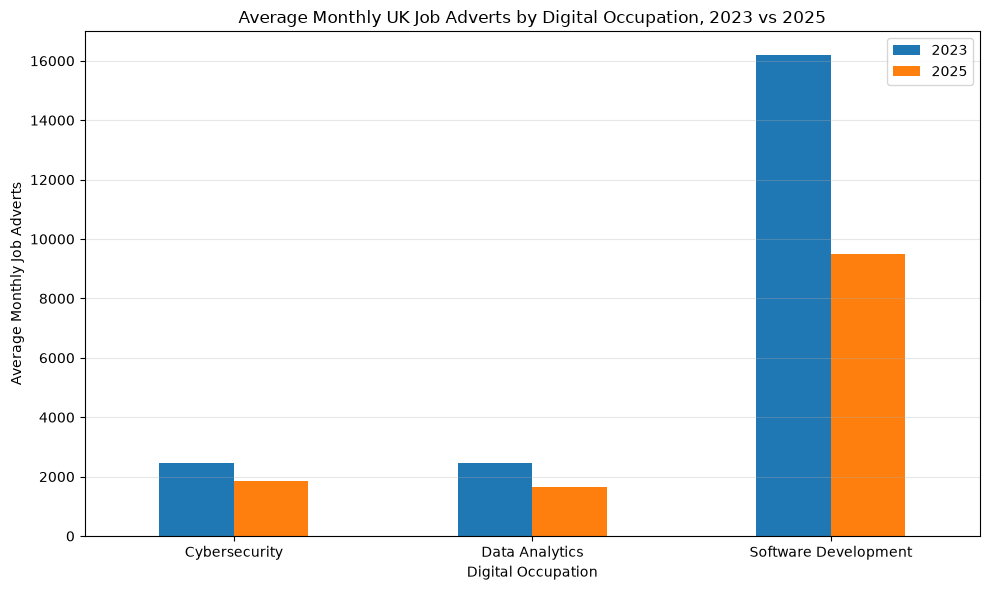

Saved: D:\MScProjects\labour-market-intelligence\results\final_uk_demand_2023_vs_2025.png


In [16]:
# ============================================================
# STEP 4.2 — UK digital job-demand comparison
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path(
    r"D:\MScProjects\labour-market-intelligence\results"
)

results_path.mkdir(parents=True, exist_ok=True)

plot_df = summary[
    [
        "Skill_Category",
        "Average_Monthly_Adverts_2023",
        "Average_Monthly_Adverts_2025"
    ]
].copy()

plot_df = plot_df.set_index("Skill_Category")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Monthly UK Job Adverts by Digital Occupation, 2023 vs 2025")
plt.xlabel("Digital Occupation")
plt.ylabel("Average Monthly Job Adverts")
plt.xticks(rotation=0)
plt.legend(["2023", "2025"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

output_path = results_path / "final_uk_demand_2023_vs_2025.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

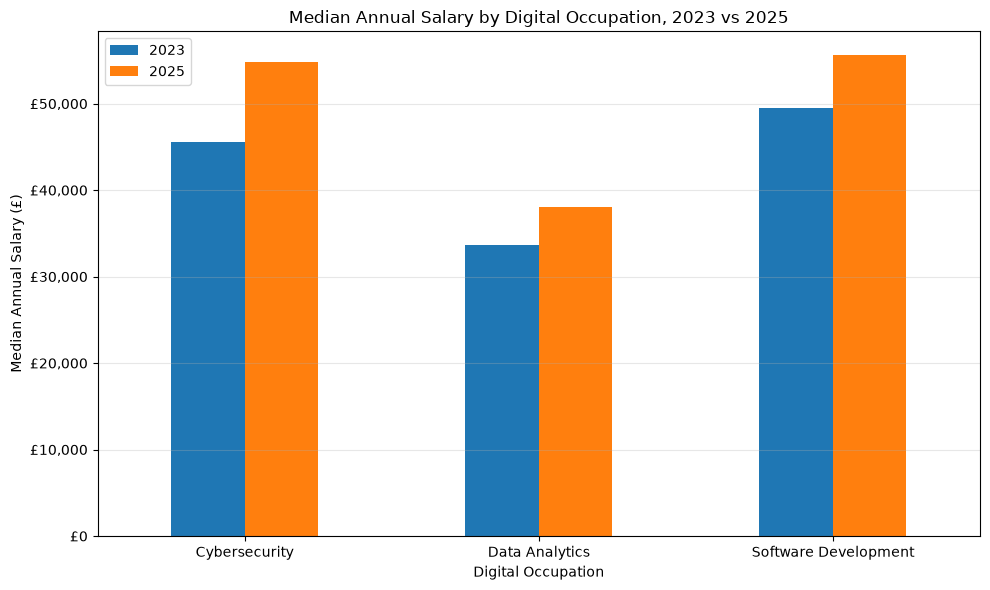

Saved: D:\MScProjects\labour-market-intelligence\results\final_uk_salary_2023_vs_2025.png


In [17]:
# ============================================================
# STEP 4.3 — UK digital salary comparison
# ============================================================

plot_salary = summary[
    [
        "Skill_Category",
        "Median_Annual_Salary_2023",
        "Median_Annual_Salary_2025"
    ]
].copy()

plot_salary = plot_salary.set_index("Skill_Category")

ax = plot_salary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Median Annual Salary by Digital Occupation, 2023 vs 2025")
plt.xlabel("Digital Occupation")
plt.ylabel("Median Annual Salary (£)")
plt.xticks(rotation=0)

plt.legend(["2023", "2025"])

plt.grid(axis="y", alpha=0.3)

# Format salary axis
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()

output_path = (
    results_path /
    "final_uk_salary_2023_vs_2025.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

In [1]:
# ============================================================
# STEP 4.4 — Demand change vs salary change, 2023–2025
# ============================================================

change_df = summary[
    [
        "Skill_Category",
        "Demand_Change_Pct",
        "Salary_Change_Pct"
    ]
].copy()

change_df = change_df.set_index("Skill_Category")

# ------------------------------------------------------------
# Plot demand and salary change
# ------------------------------------------------------------

ax = change_df.plot(
    kind="bar",
    figsize=(10, 6)
)

# Capture ONLY the two bar-series handles
bar_handles, _ = ax.get_legend_handles_labels()

# Add zero reference line AFTER capturing bar handles
ax.axhline(
    y=0,
    linewidth=1
)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

ax.set_title(
    "Change in UK Digital Job Demand and Median Salary, 2023–2025"
)

ax.set_xlabel("Digital Occupation")
ax.set_ylabel("Percentage Change (%)")

plt.xticks(rotation=0)

# Explicitly use the two BAR handles in the legend
ax.legend(
    bar_handles,
    ["Job Demand", "Median Salary"]
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    results_path /
    "final_demand_salary_change_2023_2025.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

# ------------------------------------------------------------
# Display underlying values
# ------------------------------------------------------------

print("\nUnderlying values:")

print(
    summary[
        [
            "Skill_Category",
            "Demand_Change_Pct",
            "Salary_Change_Pct"
        ]
    ].to_string(index=False)
)

NameError: name 'summary' is not defined

2025 REGIONAL SALARIES
Region                 London  North West  West Midlands
Skill_Category                                          
Cybersecurity         59590.0     51954.0            NaN
Data Analytics        42850.0     33871.0        44172.0
Software Development  74284.0     49505.0        47744.0


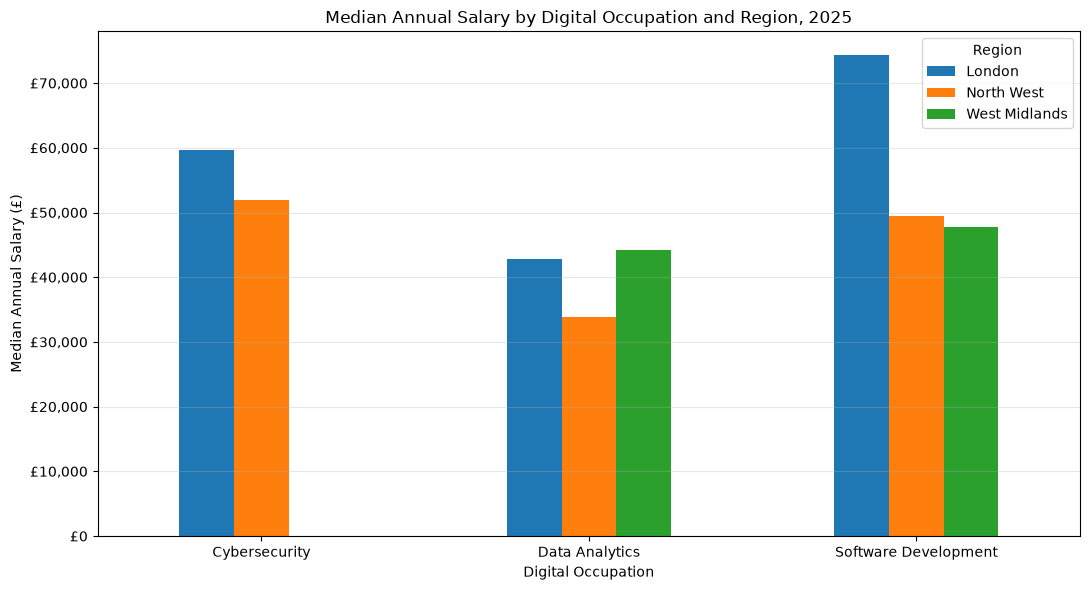


Saved: D:\MScProjects\labour-market-intelligence\results\final_regional_salary_comparison_2025.png


In [19]:
# ============================================================
# STEP 4.5 — Regional digital salary comparison, 2025
# ============================================================

regional_df = pd.read_csv(
    processed_path /
    "regional_labour_market_final_2023_2025.csv"
)

regional_2025 = regional_df[
    regional_df["Year"] == 2025
].copy()

# Keep available salary observations only
regional_plot = (
    regional_2025[
        regional_2025["Median_Annual_Salary"].notna()
    ]
    .pivot(
        index="Skill_Category",
        columns="Region",
        values="Median_Annual_Salary"
    )
)

print("2025 REGIONAL SALARIES")
print("=" * 80)
print(regional_plot)

ax = regional_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Median Annual Salary by Digital Occupation and Region, 2025")
plt.xlabel("Digital Occupation")
plt.ylabel("Median Annual Salary (£)")
plt.xticks(rotation=0)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.grid(axis="y", alpha=0.3)
plt.legend(title="Region")

plt.tight_layout()

output_path = (
    results_path /
    "final_regional_salary_comparison_2025.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", output_path)

REGIONAL DEMAND: 2023 vs 2025
Year               2023      2025
Region                           
London         164341.2  121131.8
North West      88384.1   77827.8
West Midlands   67152.2   59020.1

REGIONAL DEMAND CHANGE
Year               2023      2025  Change_Pct
Region                                       
London         164341.2  121131.8      -26.29
North West      88384.1   77827.8      -11.94
West Midlands   67152.2   59020.1      -12.11


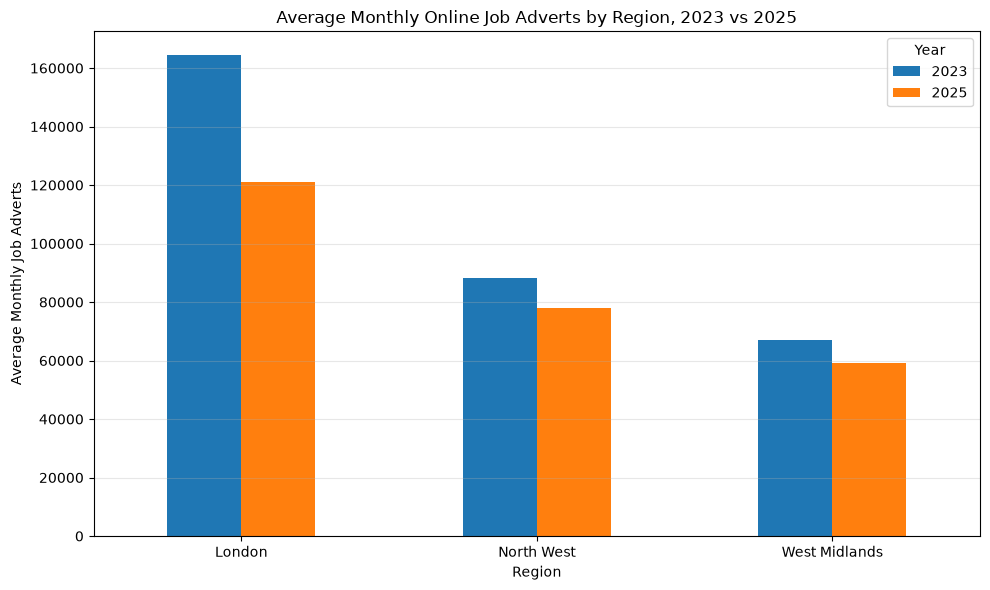


Saved: D:\MScProjects\labour-market-intelligence\results\final_regional_demand_2023_vs_2025.png


In [20]:
# ============================================================
# STEP 4.6 — Regional job-demand change, 2023–2025
# ============================================================

regional_demand = (
    regional_df[
        ["Year", "Region", "Regional_Average_Monthly_Adverts"]
    ]
    .drop_duplicates()
)

regional_demand = regional_demand[
    regional_demand["Year"].isin([2023, 2025])
]

regional_demand_plot = regional_demand.pivot(
    index="Region",
    columns="Year",
    values="Regional_Average_Monthly_Adverts"
)

print("REGIONAL DEMAND: 2023 vs 2025")
print("=" * 70)
print(regional_demand_plot)

# Calculate percentage change
regional_demand_plot["Change_Pct"] = (
    (
        regional_demand_plot[2025]
        / regional_demand_plot[2023]
        - 1
    ) * 100
).round(2)

print("\nREGIONAL DEMAND CHANGE")
print("=" * 70)
print(regional_demand_plot)

# Plot only 2023 and 2025
ax = regional_demand_plot[[2023, 2025]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Monthly Online Job Adverts by Region, 2023 vs 2025")
plt.xlabel("Region")
plt.ylabel("Average Monthly Job Adverts")

plt.xticks(rotation=0)
plt.legend(title="Year")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

output_path = (
    results_path /
    "final_regional_demand_2023_vs_2025.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", output_path)

O*NET SKILL IMPORTANCE MATRIX
Title                  Database Administrators  Information Security Analysts  Software Developers  Statisticians
Element Name                                                                                                     
Active Learning                           3.50                           3.25                 3.50           3.75
Active Listening                          3.75                           3.75                 3.38           3.88
Critical Thinking                         3.88                           3.88                 3.88           4.00
Learning Strategies                       3.00                           2.88                 2.62           3.12
Mathematics                               3.00                           2.25                 2.75           4.88
Monitoring                                3.25                           3.38                 3.00           3.00
Reading Comprehension                     3.75            

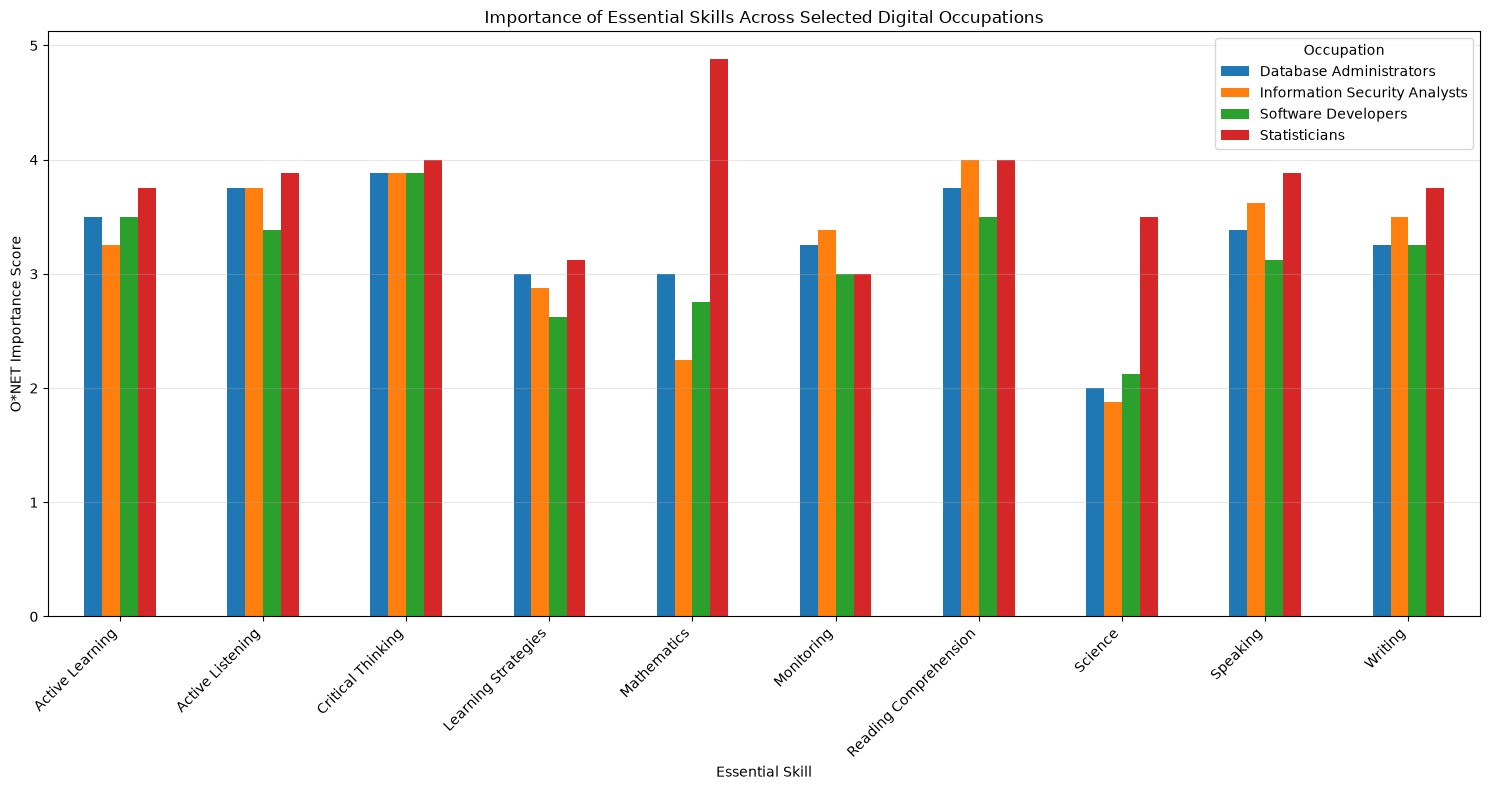


Saved: D:\MScProjects\labour-market-intelligence\results\onet_essential_skills_comparison.png


In [21]:
# ============================================================
# Step 4.7 — O*NET Essential Skills Comparison
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_path = Path(
    r"D:\MScProjects\labour-market-intelligence"
)

processed_path = project_path / "data" / "processed"
results_path = project_path / "results"

skills = pd.read_csv(
    processed_path / "onet_occupation_skill_profiles.csv"
)

# Create occupation × skill matrix
skill_matrix = skills.pivot(
    index="Element Name",
    columns="Title",
    values="Importance"
)

print("O*NET SKILL IMPORTANCE MATRIX")
print("=" * 80)
print(skill_matrix.round(2).to_string())

# Plot
ax = skill_matrix.plot(
    kind="bar",
    figsize=(15, 8)
)

ax.set_title(
    "Importance of Essential Skills Across Selected Digital Occupations"
)
ax.set_xlabel("Essential Skill")
ax.set_ylabel("O*NET Importance Score")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Occupation")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_file = results_path / "onet_essential_skills_comparison.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", output_file)

DIGITAL TECHNOLOGY SUMMARY
Skill_Category  Unique_Technologies  Hot_Technologies  In_Demand_Technologies  Hot_Technology_Pct  In_Demand_Pct
            AI                    3                 2                       2               66.67          66.67
 Cybersecurity                   17                 0                       1                0.00           5.88
Data Analytics                   27                13                      11               48.15          40.74


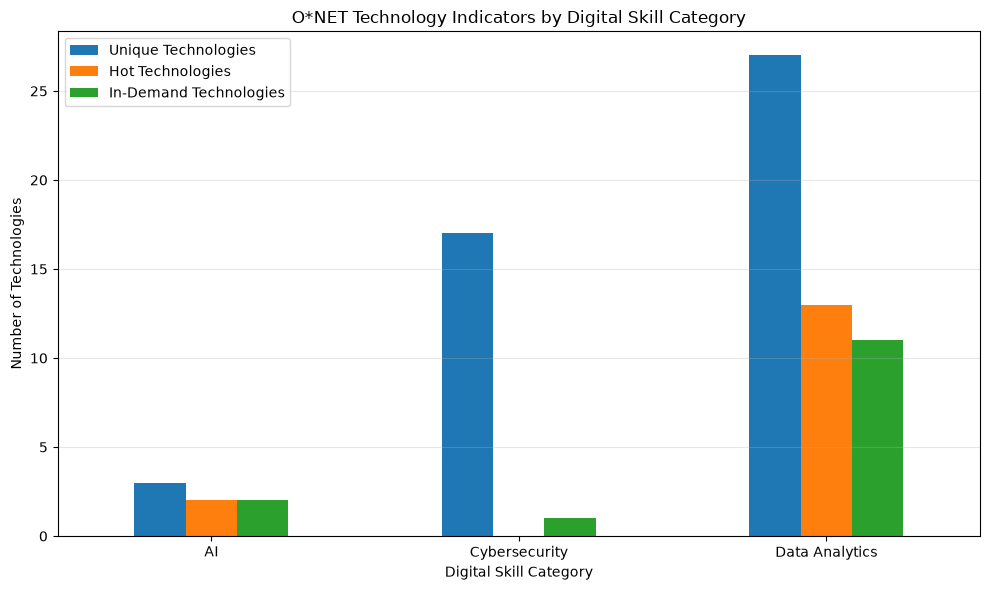


Saved: D:\MScProjects\labour-market-intelligence\results\onet_technology_demand_indicators.png


In [23]:
# ============================================================
# Step 4.8 — Digital Technology Demand Indicators
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

tech_summary = pd.read_csv(
    processed_path / "digital_technology_category_summary.csv"
)

print("DIGITAL TECHNOLOGY SUMMARY")
print("=" * 70)
print(tech_summary.to_string(index=False))

plot_df = tech_summary.set_index("Skill_Category")[
    [
        "Unique_Technologies",
        "Hot_Technologies",
        "In_Demand_Technologies"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("O*NET Technology Indicators by Digital Skill Category")
ax.set_xlabel("Digital Skill Category")
ax.set_ylabel("Number of Technologies")

plt.xticks(rotation=0)
plt.legend(
    ["Unique Technologies", "Hot Technologies", "In-Demand Technologies"]
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_file = results_path / "onet_technology_demand_indicators.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", output_file)

In [24]:
# ============================================================
# Step 4.9 — Leading Digital Technologies
# ============================================================

tech = pd.read_csv(
    processed_path / "digital_technology_demand_indicators.csv"
)

# Focus on technologies with strongest evidence
top_tech = (
    tech
    .sort_values(
        ["Indicator_Score", "Occupation_Count"],
        ascending=[False, False]
    )
    .groupby("Skill_Category", group_keys=False)
    .head(8)
)

print("LEADING DIGITAL TECHNOLOGIES")
print("=" * 90)

for category in top_tech["Skill_Category"].unique():
    print(f"\n--- {category} ---")
    print(
        top_tech[
            top_tech["Skill_Category"] == category
        ][
            [
                "Workplace Example",
                "Occupation_Count",
                "Hot_Technology",
                "In_Demand",
                "Technology_Status"
            ]
        ].to_string(index=False)
    )

# Save evidence table
output_file = processed_path / "leading_digital_technologies.csv"

top_tech.to_csv(output_file, index=False)

print("\nSaved:", output_file)

LEADING DIGITAL TECHNOLOGIES

--- Data Analytics ---
            Workplace Example  Occupation_Count  Hot_Technology  In_Demand Technology_Status
Structured query language SQL               151               1          1   Hot + In Demand
                       Python               132               1          1   Hot + In Demand
         Microsoft SQL Server                94               1          1   Hot + In Demand
                      Tableau                73               1          1   Hot + In Demand
                        MySQL                50               1          1   Hot + In Demand
                   PostgreSQL                31               1          1   Hot + In Demand
                        NoSQL                30               1          1   Hot + In Demand
           Microsoft Power BI                25               1          1   Hot + In Demand

--- AI ---
               Workplace Example  Occupation_Count  Hot_Technology  In_Demand Technology_Status
  

In [ ]:
# ============================================================
# Step 4.10 — Final Evidence Coverage Matrix
# ============================================================

evidence = pd.read_csv(
    processed_path / "integrated_skills_labour_market_evidence.csv"
)

coverage = evidence[
    [
        "Skill_Category",
        "UK_Labour_Market_Evidence",
        "ONet_Skill_Evidence",
        "ONet_Technology_Evidence"
    ]
].copy()

coverage["Evidence_Sources_Available"] = (
    coverage[
        [
            "UK_Labour_Market_Evidence",
            "ONet_Skill_Evidence",
            "ONet_Technology_Evidence"
        ]
    ]
    .sum(axis=1)
)

coverage["Evidence_Coverage"] = coverage[
    "Evidence_Sources_Available"
].map({
    3: "Full",
    2: "Partial",
    1: "Limited",
    0: "None"
})

print("FINAL EVIDENCE COVERAGE MATRIX")
print("=" * 90)
print(coverage.to_string(index=False))

output_file = processed_path / "final_evidence_coverage_matrix.csv"

coverage.to_csv(output_file, index=False)

print("\nSaved:", output_file)

FINAL EVIDENCE COVERAGE MATRIX
      Skill_Category  UK_Labour_Market_Evidence  ONet_Skill_Evidence  ONet_Technology_Evidence  Evidence_Sources_Available Evidence_Coverage
                  AI                      False                False                      True                           1           Limited
       Cybersecurity                       True                 True                      True                           3              Full
      Data Analytics                       True                 True                      True                           3              Full
Software Development                       True                 True                     False                           2           Partial

Saved: D:\MScProjects\labour-market-intelligence\data\processed\final_evidence_coverage_matrix.csv
